In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('DATASET/student_productivity_distraction_dataset_20000.csv')
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


# EDA - analiza exploratorie

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  str    
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  focus_score  

In [4]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [5]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='str')

target: productivity_score si final_grade

### Studiul influenteaza nota?

<Axes: xlabel='study_hours_per_day', ylabel='final_grade'>

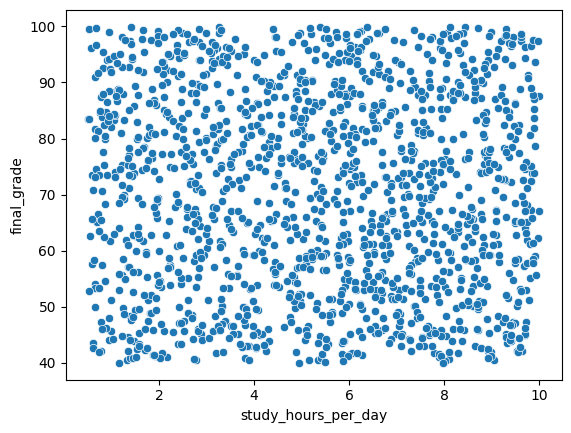

In [6]:
df_sample = df.sample(1500)
sns.scatterplot(x='study_hours_per_day', y='final_grade', data=df_sample)

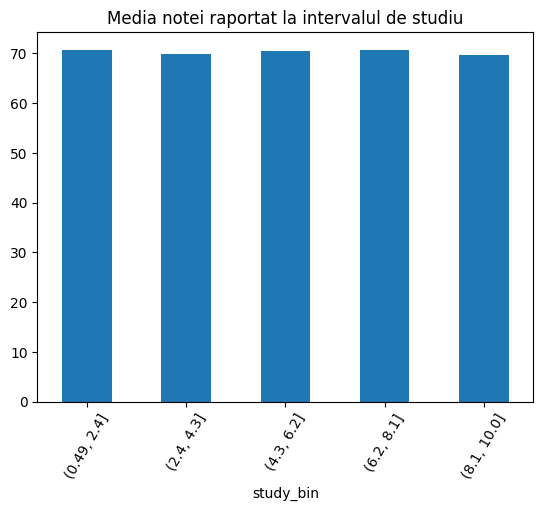

In [7]:
df['study_bin'] = pd.cut(df['study_hours_per_day'], bins=5)

df.groupby('study_bin')['final_grade'].mean().plot(kind='bar')
plt.title("Media notei raportat la intervalul de studiu")
plt.xticks(rotation=60)
plt.show()

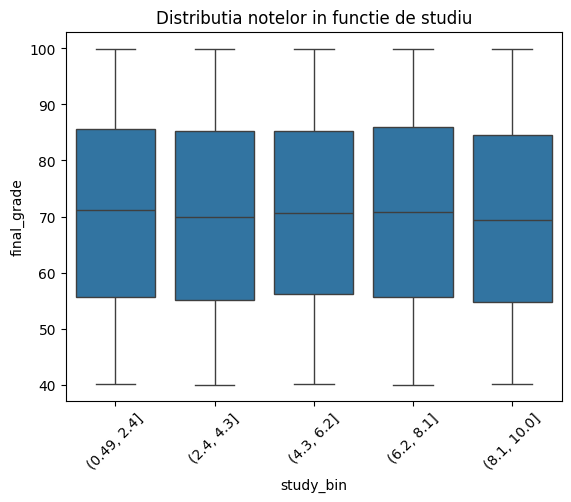

In [8]:
sns.boxplot(x='study_bin', y='final_grade', data=df)
plt.xticks(rotation=45)
plt.title("Distributia notelor in functie de studiu")
plt.show()

### Social media influenteaza nota finala?

<Axes: xlabel='social_media_hours', ylabel='final_grade'>

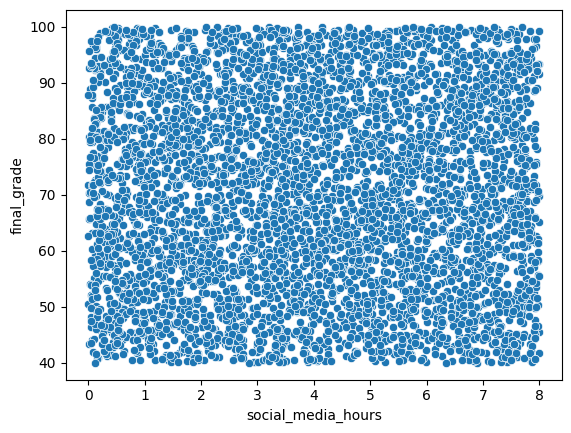

In [9]:
df_sample = df.sample(5000)

sns.scatterplot(
    x='social_media_hours',
    y='final_grade',
    data=df_sample,
)

Orele petrecute pe social media nu influenteaza final_grade in mare masura!!
DE CE? pentru ca am luat diferite sample-uri, de dimensiuni tot mai mari, iar distributia punctelor a ramas destul de omogena
Se confirma acest lucru si prin matricea de corelatie de mai jos.

### Heatmap corelatie

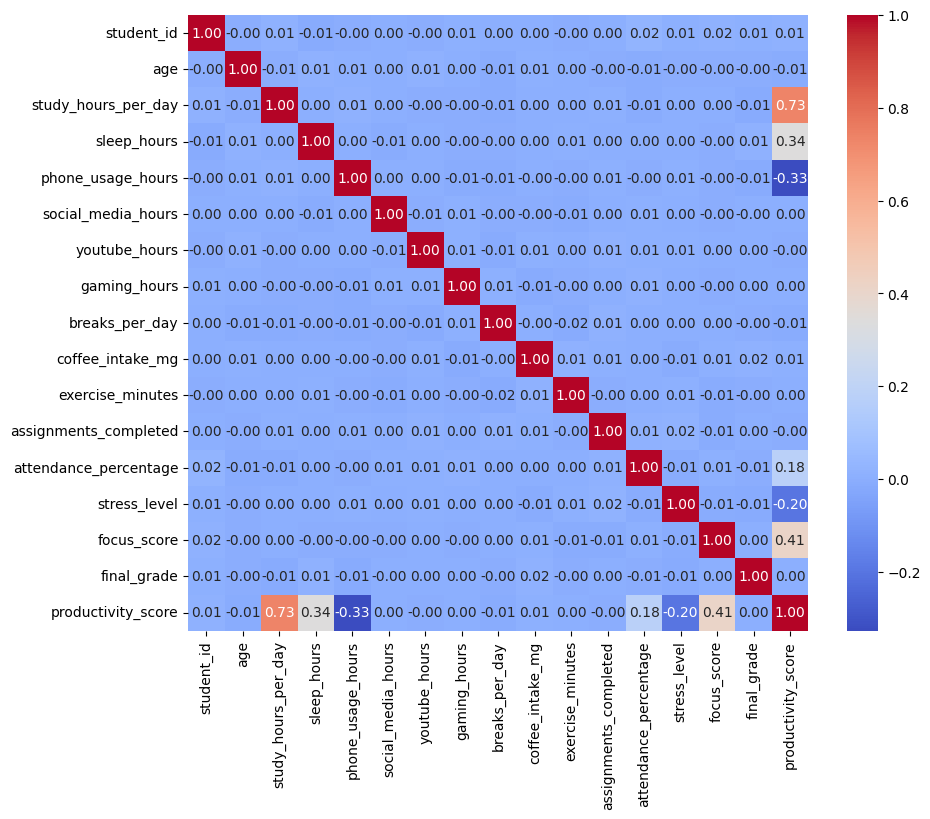

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [11]:
df.isnull().sum()

student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
study_bin                0
dtype: int64

Nu exista valori lipsa hehe

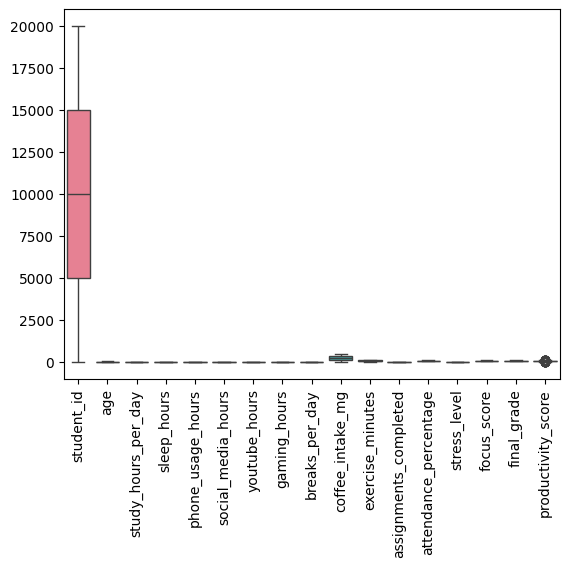

In [12]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

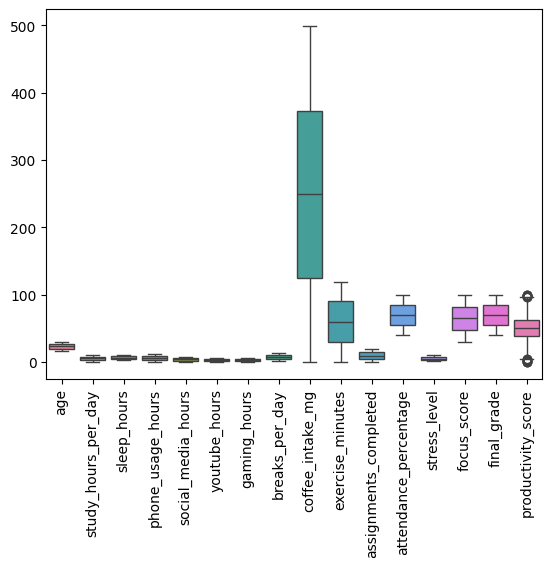

In [13]:
df_no_id = df.drop(columns=['student_id'])

sns.boxplot(data=df_no_id)
plt.xticks(rotation=90)
plt.show()

# Curatare date
Transformare coloana 'gender' care e string in alte 3 coloane, numerice: is_male, is_female, is_other

In [14]:
df['gender'] = df['gender'].str.lower().str.strip()

# creez noile coloane cu valori numerice
df['is_male'] = (df['gender'] == 'male').astype(int)
df['is_female'] = (df['gender'] == 'female').astype(int)
df['is_other'] = (df['gender'] == 'other').astype(int)

In [15]:
df.head

<bound method NDFrame.head of        student_id  age  gender  study_hours_per_day  sleep_hours  \
0               1   23  female                 4.35         3.63   
1               2   20    male                 6.14         6.58   
2               3   29  female                 4.98         3.26   
3               4   27  female                 3.19         4.58   
4               5   24    male                 7.67         6.21   
...           ...  ...     ...                  ...          ...   
19995       19996   26  female                 4.81         7.83   
19996       19997   22   other                 0.83         4.49   
19997       19998   25    male                 9.36         4.33   
19998       19999   22  female                 0.74         4.44   
19999       20000   19  female                 3.64         6.35   

       phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
0                   3.38                2.73           1.83          5.26   

In [ ]:
#sterg coloana veche gender, care e string
df.drop(columns=['gender'], inplace=True)


In [17]:
df.columns

Index(['student_id', 'age', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score',
       'study_bin', 'is_male', 'is_female', 'is_other'],
      dtype='str')